# Financial Fraud Detection System
### Month 2 Project — Amdox Technologies
**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions using a real-world synthetic dataset of 50,000 records.

## 1. Importing Libraries

In [1]:
# 1. Importing Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib
import os

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading Dataset

In [2]:
# 2. Loading Dataset 

df = pd.read_csv('../data/creditcard.csv')
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFraud distribution:")
print(df['Class'].value_counts())
print(f"\nFraud %: {df['Class'].mean()*100:.4f}%")

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Fraud distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%


## 3. Exploratory Data Analysis

In [3]:
# 3. Exploratory Data Analysis

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21   

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# 3.1 Checking Null and Duplicate Values

print("Null Values:")
print(df.isnull().sum().sum(), "null values found")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Null Values:
0 null values found

Duplicate Rows: 1081


Fraud Label Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


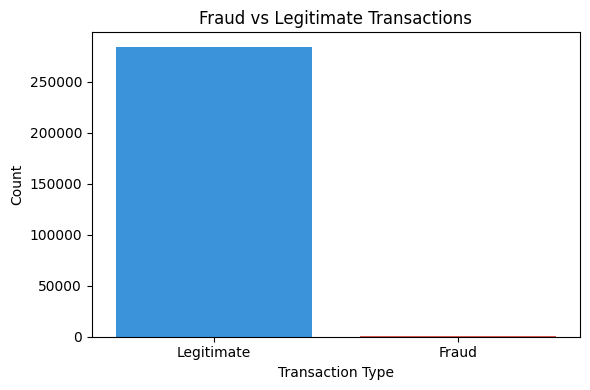

In [5]:
# 3.2 Fraud Label Distribution

print("Fraud Label Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].mean()*100:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2196F3','#F44336'])
plt.title('Fraud vs Legitimate Transactions')
plt.xticks([0,1], ['Legitimate','Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_01_fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

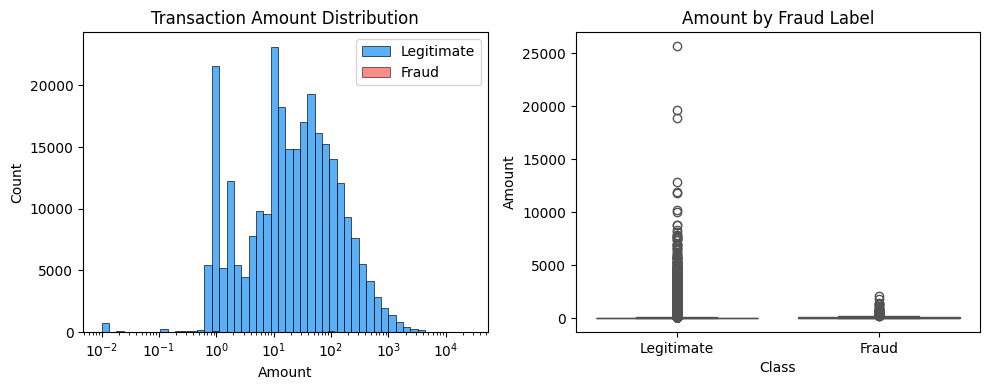

In [6]:
# 3.3 Transaction Amount Distribution

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], color='#2196F3', 
             label='Legitimate', bins=50, log_scale=True)
sns.histplot(df[df['Class']==1]['Amount'], color='#F44336', 
             label='Fraud', bins=50, alpha=0.6, log_scale=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x='Class', y='Amount', data=df, palette=['#2196F3','#F44336'])
plt.title('Amount by Fraud Label')
plt.xticks([0,1], ['Legitimate','Fraud'])

plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

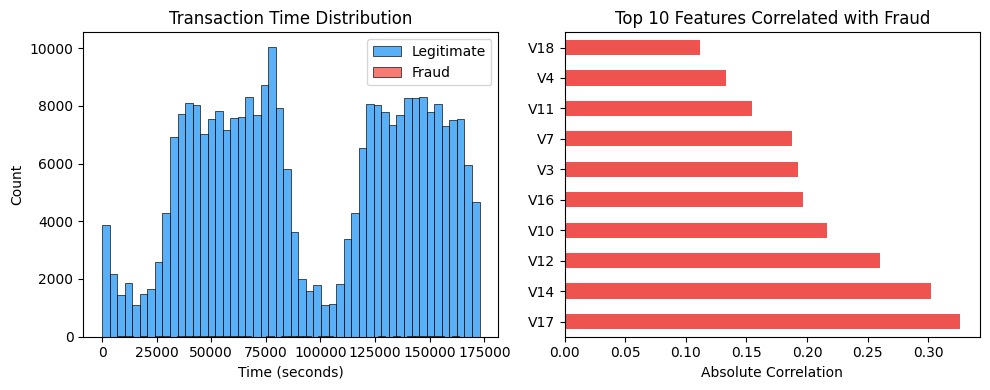

In [7]:
# 3.4 Transaction Time Distribution

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Time'], color='#2196F3', 
             label='Legitimate', bins=50)
sns.histplot(df[df['Class']==1]['Time'], color='#F44336', 
             label='Fraud', bins=50, alpha=0.7)
plt.title('Transaction Time Distribution')
plt.xlabel('Time (seconds)')
plt.legend()

plt.subplot(1,2,2)
# Top 10 PCA features correlation with fraud
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
corr.plot(kind='barh', color='#EF5350')
plt.title('Top 10 Features Correlated with Fraud')
plt.xlabel('Absolute Correlation')

plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_03_time_and_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

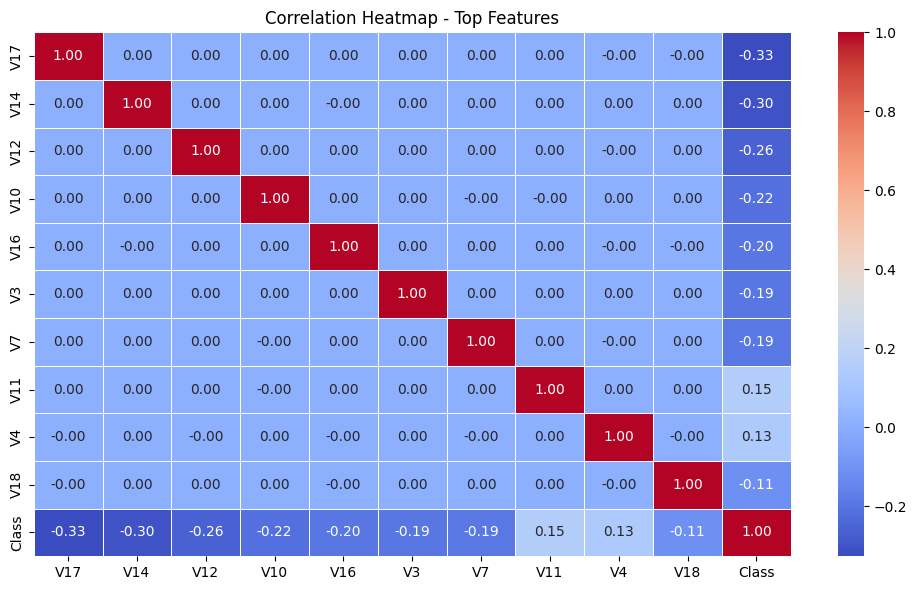

In [8]:
# 3.5 Correlation Heatmap (Top PCA Features)

top_features = corr.index.tolist()[:10] + ['Class']
plt.figure(figsize=(10,6))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [9]:
# 4.1 Feature Engineering

df['Amount_log'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] % 86400) // 3600  # extract hour from seconds
df['High_Amount'] = (df['Amount'] > df['Amount'].quantile(0.90)).astype(int)

# Drop original Time and Amount (replaced by engineered features)
df = df.drop(columns=['Time', 'Amount'])

print("Feature engineering done.")
print(f"Shape: {df.shape}")
display(df.head())

Feature engineering done.
Shape: (284807, 32)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour,High_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760,0.0,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626,0.0,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276,0.0,1
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306,0.0,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539,0.0,0


In [10]:
# 4.2 Feature and Target Split

X = df.drop(columns=['Class'])
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTotal features: {len(X.columns)}")

Features shape: (284807, 31)
Target shape: (284807,)

Total features: 31


In [11]:
# 4.3 Train Test Split first (before SMOTE to avoid data leakage)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nFraud in train: {y_train.sum()}")
print(f"Fraud in test: {y_test.sum()}")

Training set: (227845, 31)
Testing set: (56962, 31)

Fraud in train: 394
Fraud in test: 98


In [12]:
# 4.4 Standardization

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Standardization done.")
print(f"X_train_sc shape: {X_train_sc.shape}")

Standardization done.
X_train_sc shape: (227845, 31)


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    113725
Name: count, dtype: int64


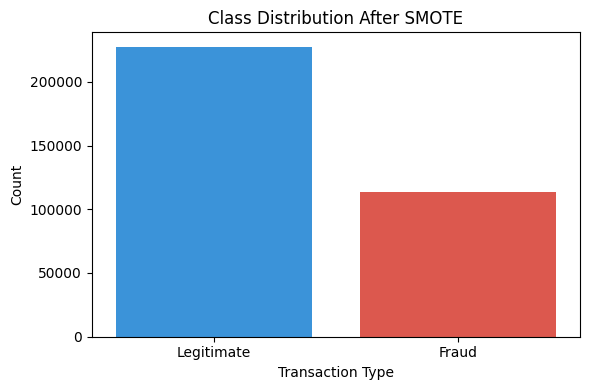

In [13]:
# 4.5 Handling Class Imbalance using SMOTE (applied only on train set)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res, palette=['#2196F3','#F44336'])
plt.title('Class Distribution After SMOTE')
plt.xticks([0,1], ['Legitimate','Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_05_smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Machine Learning Models

In [14]:
# 5. Model Training and Evaluation

def evaluate_model(model_name, y_test, y_pred, y_proba):
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['Legitimate','Fraud']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate','Fraud'],
                yticklabels=['Legitimate','Fraud'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'../exports/notebook_charts/img_confusion_{model_name.replace(" ","_")}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

    return acc, auc

results = {}


Model: Logistic Regression
Accuracy:  98.60%
ROC-AUC:   0.9720

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.10      0.91      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962



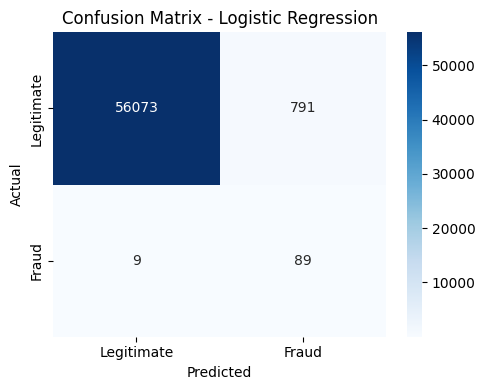

In [15]:
# 5.1 Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:,1]

acc_lr, auc_lr = evaluate_model("Logistic Regression", 
                                 y_test, y_pred_lr, y_proba_lr)
results['Logistic Regression'] = {'Accuracy': acc_lr, 'ROC-AUC': auc_lr}


Model: Decision Tree
Accuracy:  99.33%
ROC-AUC:   0.8921

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56864
       Fraud       0.18      0.85      0.30        98

    accuracy                           0.99     56962
   macro avg       0.59      0.92      0.65     56962
weighted avg       1.00      0.99      1.00     56962



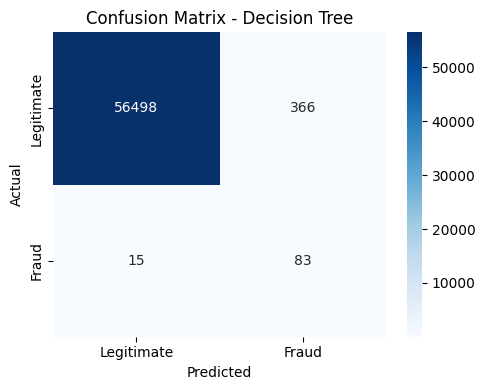

In [16]:
# 5.2 Decision Tree

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test_sc)
y_proba_dt = dt.predict_proba(X_test_sc)[:,1]

acc_dt, auc_dt = evaluate_model("Decision Tree", 
                                 y_test, y_pred_dt, y_proba_dt)
results['Decision Tree'] = {'Accuracy': acc_dt, 'ROC-AUC': auc_dt}


Model: Random Forest
Accuracy:  99.90%
ROC-AUC:   0.9829

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.68      0.84      0.75        98

    accuracy                           1.00     56962
   macro avg       0.84      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



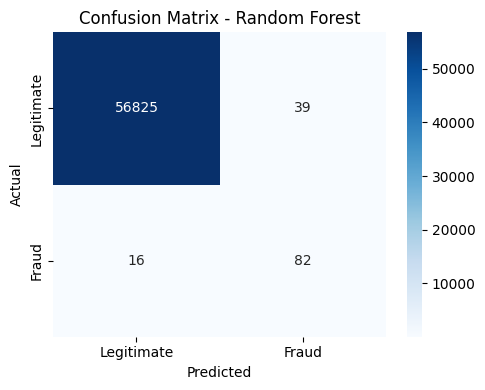

In [17]:
# 5.3 Random Forest

rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                             class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_sc)
y_proba_rf = rf.predict_proba(X_test_sc)[:,1]

acc_rf, auc_rf = evaluate_model("Random Forest", 
                                 y_test, y_pred_rf, y_proba_rf)
results['Random Forest'] = {'Accuracy': acc_rf, 'ROC-AUC': auc_rf}


Model: XGBoost
Accuracy:  98.91%
ROC-AUC:   0.9825

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.13      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



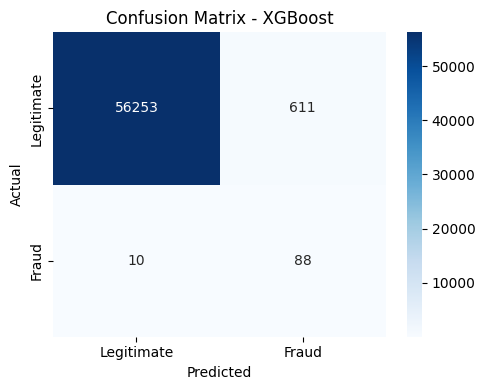

In [18]:
# 5.4 XGBoost

xgb = XGBClassifier(n_estimators=200, max_depth=6,
                     learning_rate=0.05, subsample=0.8,
                     colsample_bytree=0.8, scale_pos_weight=50,
                     random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test_sc)
y_proba_xgb = xgb.predict_proba(X_test_sc)[:,1]

acc_xgb, auc_xgb = evaluate_model("XGBoost", 
                                    y_test, y_pred_xgb, y_proba_xgb)
results['XGBoost'] = {'Accuracy': acc_xgb, 'ROC-AUC': auc_xgb}


Model: Isolation Forest
Accuracy:  99.83%
ROC-AUC:   0.9079

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



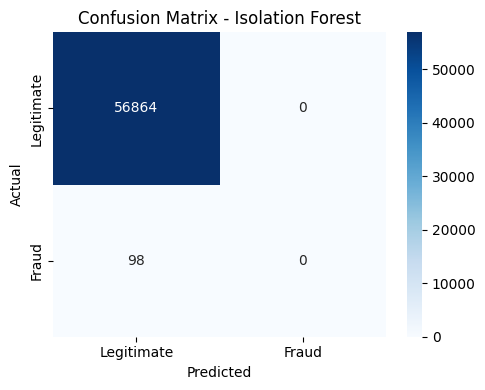

In [19]:
# 5.5 Isolation Forest

iso = IsolationForest(contamination=0.002, random_state=42)
iso.fit(X_train_res)

y_pred_iso_raw = iso.predict(X_test_sc)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso_raw]
y_proba_iso = [-x for x in iso.score_samples(X_test_sc)]
y_proba_iso = (y_proba_iso - np.min(y_proba_iso)) / \
              (np.max(y_proba_iso) - np.min(y_proba_iso))

acc_iso, auc_iso = evaluate_model("Isolation Forest", 
                                   y_test, y_pred_iso, y_proba_iso)
results['Isolation Forest'] = {'Accuracy': acc_iso, 'ROC-AUC': auc_iso}

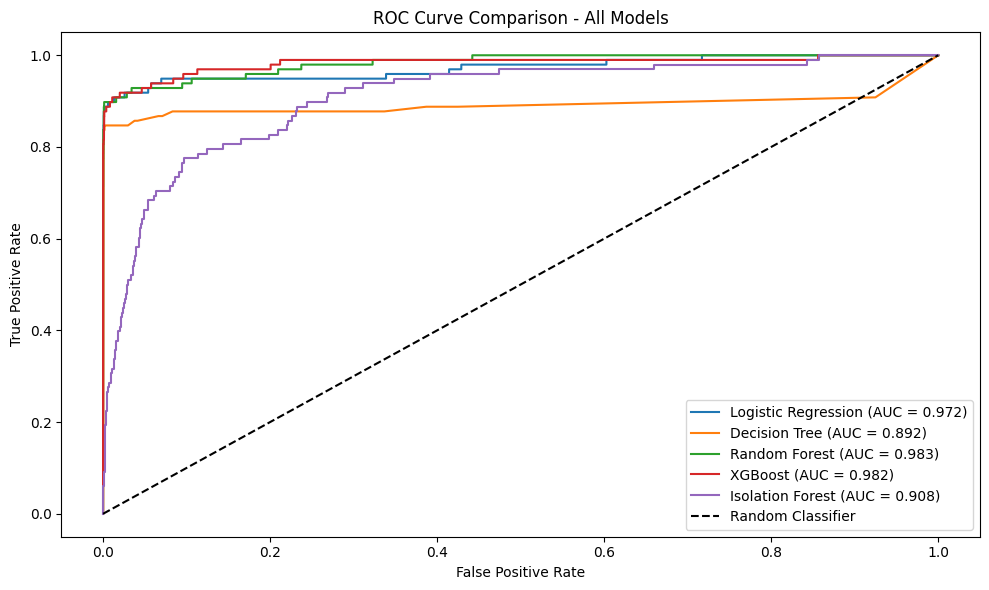

In [20]:
# 5.6 ROC Curve Comparison

plt.figure(figsize=(10,6))

models_proba = {
    'Logistic Regression': y_proba_lr,
    'Decision Tree': y_proba_dt,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'Isolation Forest': y_proba_iso
}

for model_name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Model Performance Summary:


,Accuracy,ROC-AUC
Random Forest,0.999034,0.982938
XGBoost,0.989098,0.982452
Logistic Regression,0.985956,0.971984
Isolation Forest,0.998280,0.907901
Decision Tree,0.993311,0.892061


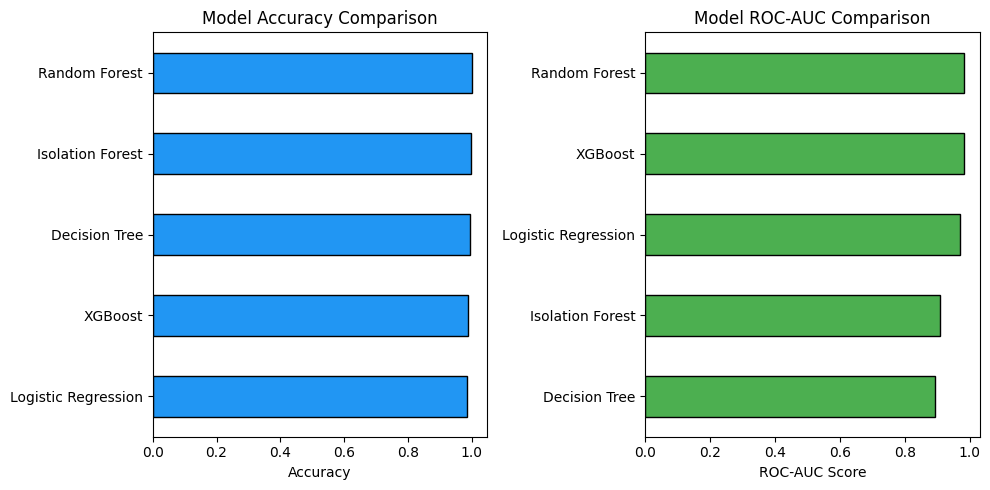

In [21]:
# 5.7 Model Comparison Summary

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Model Performance Summary:")
display(results_df)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
results_df['Accuracy'].sort_values().plot(kind='barh', 
                                           color='#2196F3', edgecolor='black')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')

plt.subplot(1,2,2)
results_df['ROC-AUC'].sort_values().plot(kind='barh', 
                                          color='#4CAF50', edgecolor='black')
plt.title('Model ROC-AUC Comparison')
plt.xlabel('ROC-AUC Score')

plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance Analysis

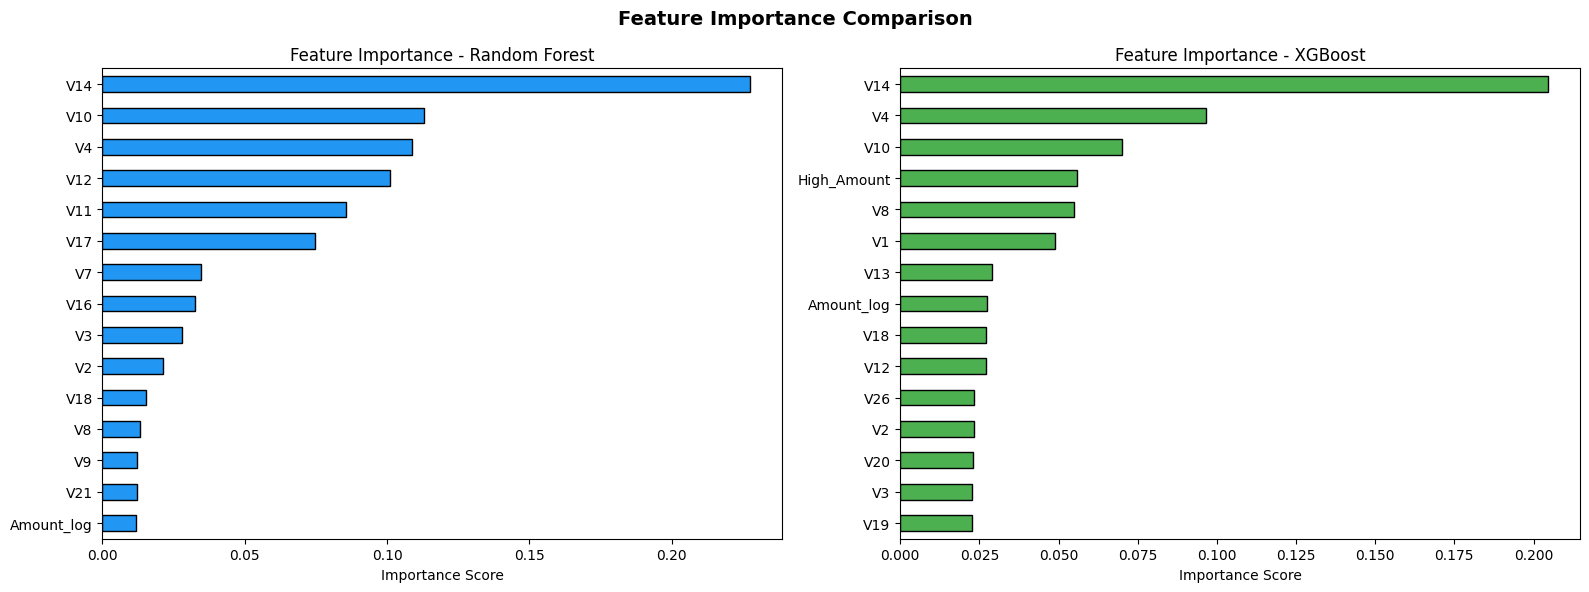

In [22]:
# 6. Feature Importance Analysis

fig, axes = plt.subplots(1, 2, figsize=(16,6))

rf_importance = pd.Series(rf.feature_importances_, 
                           index=X.columns)
rf_importance.sort_values().tail(15).plot(kind='barh', 
                                           ax=axes[0], color='#2196F3', 
                                           edgecolor='black')
axes[0].set_title('Feature Importance - Random Forest')
axes[0].set_xlabel('Importance Score')

xgb_importance = pd.Series(xgb.feature_importances_, 
                             index=X.columns)
xgb_importance.sort_values().tail(15).plot(kind='barh', 
                                            ax=axes[1], color='#4CAF50', 
                                            edgecolor='black')
axes[1].set_title('Feature Importance - XGBoost')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/notebook_charts/img_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Saving the Best Model

In [23]:
# 7. Saving the Best Model

best_model_name = results_df['ROC-AUC'].idxmax()
print(f"Best Model: {best_model_name}")

os.makedirs('../models', exist_ok=True)

model_map = {
    'XGBoost': xgb,
    'Random Forest': rf,
    'Logistic Regression': lr,
    'Decision Tree': dt
}

if best_model_name in model_map:
    joblib.dump(model_map[best_model_name], '../models/best_model.pkl')

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le_dict if 'le_dict' in dir() else {}, '../models/label_encoders.pkl')

print(f"{best_model_name} saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

Best Model: Random Forest
Random Forest saved as best_model.pkl
Scaler saved as scaler.pkl


## 8. Exporting Predictions for Dashboard

In [24]:
# 8. Exporting Predictions for Dashboard

os.makedirs('../exports', exist_ok=True)

df_export = df.copy()
X_export = df_export.drop(columns=['Class'])
X_export_sc = scaler.transform(X_export)

best_model = joblib.load('../models/best_model.pkl')
proba_export = best_model.predict_proba(X_export_sc)[:,1]
pred_export = best_model.predict(X_export_sc)

df_export['Fraud_Probability'] = proba_export
df_export['Predicted_Label'] = pred_export
df_export['Risk_Level'] = pd.cut(
    df_export['Fraud_Probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

df_export.to_csv('../exports/fraud_predictions.csv', index=False)

print("Predictions exported successfully!")
print(f"Shape: {df_export.shape}")
print(f"\nRisk Level Distribution:")
print(df_export['Risk_Level'].value_counts())

Predictions exported successfully!
Shape: (284807, 35)

Risk Level Distribution:
Risk_Level
Low       282816
High         532
Medium       189
Name: count, dtype: int64


## 9. Final Summary

In [25]:
# 9. Final Summary

print("=" * 55)
print("       FINANCIAL FRAUD DETECTION - FINAL SUMMARY")
print("=" * 55)
print(f"\nDataset Size          : {df.shape[0]:,} transactions")
print(f"Features Used         : {X.shape[1]}")
print(f"Models Trained        : {len(results)}")
print(f"\nModel Performance:")
print("-" * 55)
for model, scores in results.items():
    print(f"  {model:<25} Acc: {scores['Accuracy']*100:.2f}%   AUC: {scores['ROC-AUC']:.4f}")
print("-" * 55)
print(f"\nBest Model            : {results_df['ROC-AUC'].idxmax()}")
print(f"Best ROC-AUC Score    : {results_df['ROC-AUC'].max():.4f}")
print(f"\nExports:")
print("  - models/best_model.pkl")
print("  - models/scaler.pkl")
print("  - exports/fraud_predictions.csv")
print("\nNotebook completed successfully!")

       FINANCIAL FRAUD DETECTION - FINAL SUMMARY

Dataset Size          : 284,807 transactions
Features Used         : 31
Models Trained        : 5

Model Performance:
-------------------------------------------------------
  Logistic Regression       Acc: 98.60%   AUC: 0.9720
  Decision Tree             Acc: 99.33%   AUC: 0.8921
  Random Forest             Acc: 99.90%   AUC: 0.9829
  XGBoost                   Acc: 98.91%   AUC: 0.9825
  Isolation Forest          Acc: 99.83%   AUC: 0.9079
-------------------------------------------------------

Best Model            : Random Forest
Best ROC-AUC Score    : 0.9829

Exports:
  - models/best_model.pkl
  - models/scaler.pkl
  - exports/fraud_predictions.csv

Notebook completed successfully!
